In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
from scipy.spatial.transform import Rotation
from tqdm import tqdm

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
DATASET_DIR = Path(r"")
IMU_ID = 1
IMU_FILENAME = f"imu_{IMU_ID:03d}.csv"
G_EARTH = 9.80665
# 初始姿态的时间，用于计算陀螺仪偏置
T_INIT = 3
# 每个姿态最小静止时间
T_WAIT = 3
# 寻找最优分类函数时的迭代次数
N_ITER = 50

In [4]:
def parse_csv(f: Path) -> np.ndarray:
    """
    读取CSV,返回imu数据。
    [0] - 时间戳
    [1,2,3] - 加速度xyz
    [4,5,6] - 陀螺仪xyz
    """
    data = np.genfromtxt(f, delimiter=',', skip_header=1, usecols=(1, 2, 3, 4, 5, 6, 7))
    return data.T


In [5]:
imu_data = parse_csv(DATASET_DIR / IMU_FILENAME)
timestamp = imu_data[0] / 1e6
timestamp -= timestamp[0]
acc = imu_data[1:4]
gyro = imu_data[4:7]

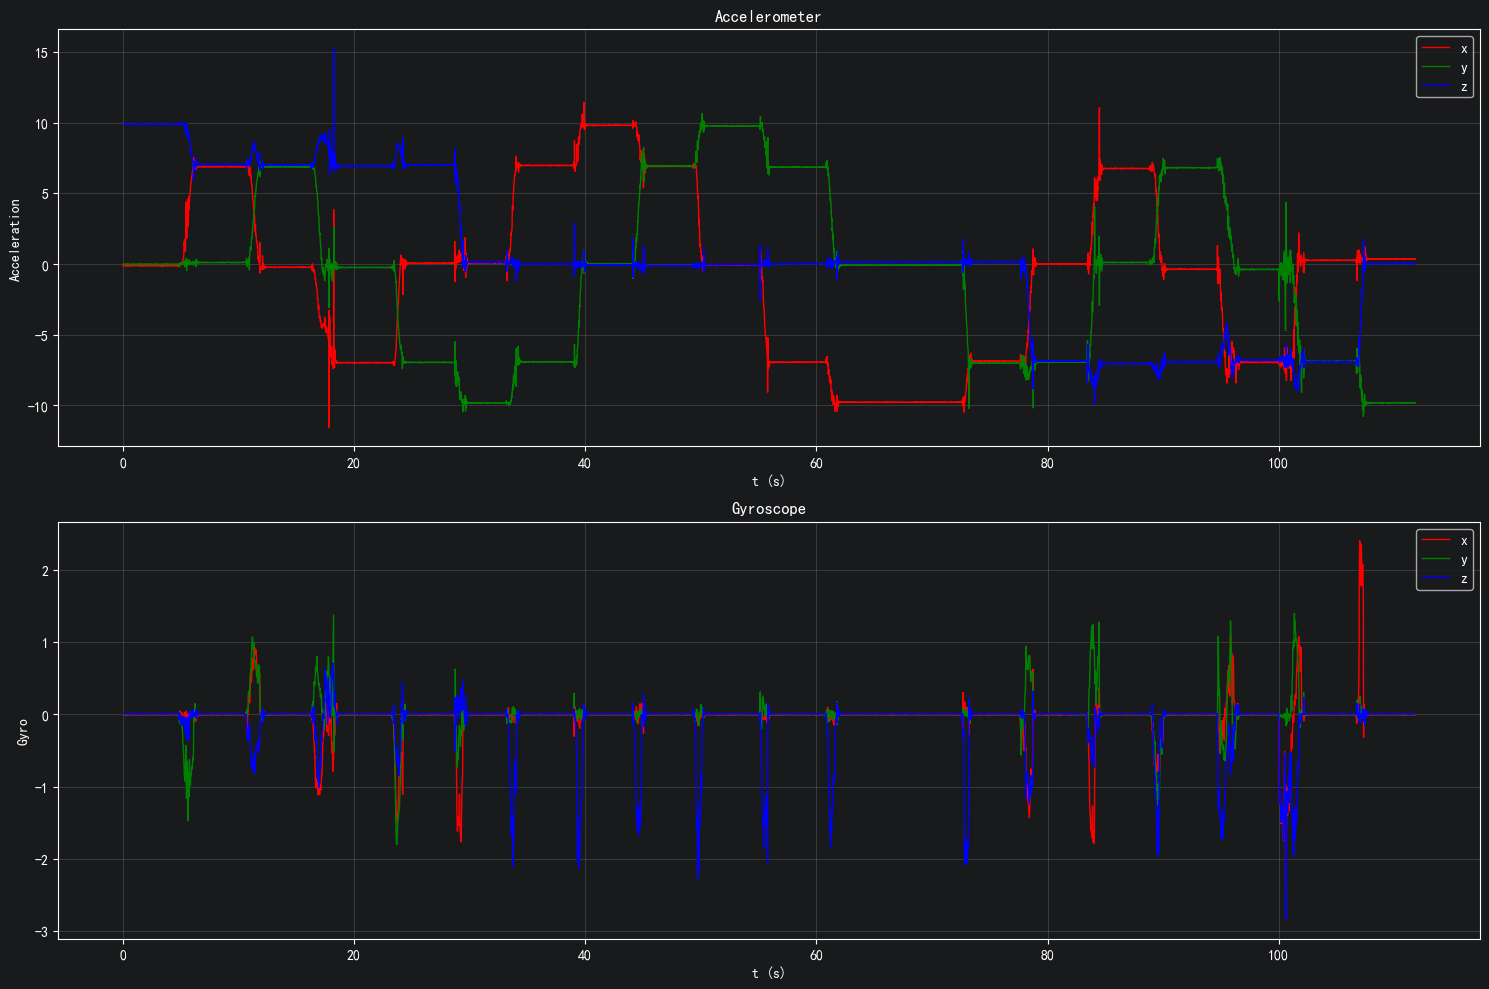

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes_labels = ['x', 'y', 'z']
colors = ['r', 'g', 'b']

# 画加速度计
for i in range(3):
    axes[0].plot(timestamp, acc[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[0].set_xlabel('t (s)')
axes[0].set_ylabel('Acceleration')
axes[0].set_title('Accelerometer')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 画陀螺仪
for i in range(3):
    axes[1].plot(timestamp, gyro[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('Gyro')
axes[1].set_title('Gyroscope')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


gyro_bias: [-5.95193034e-03  5.04876282e-05  6.40772144e-03]


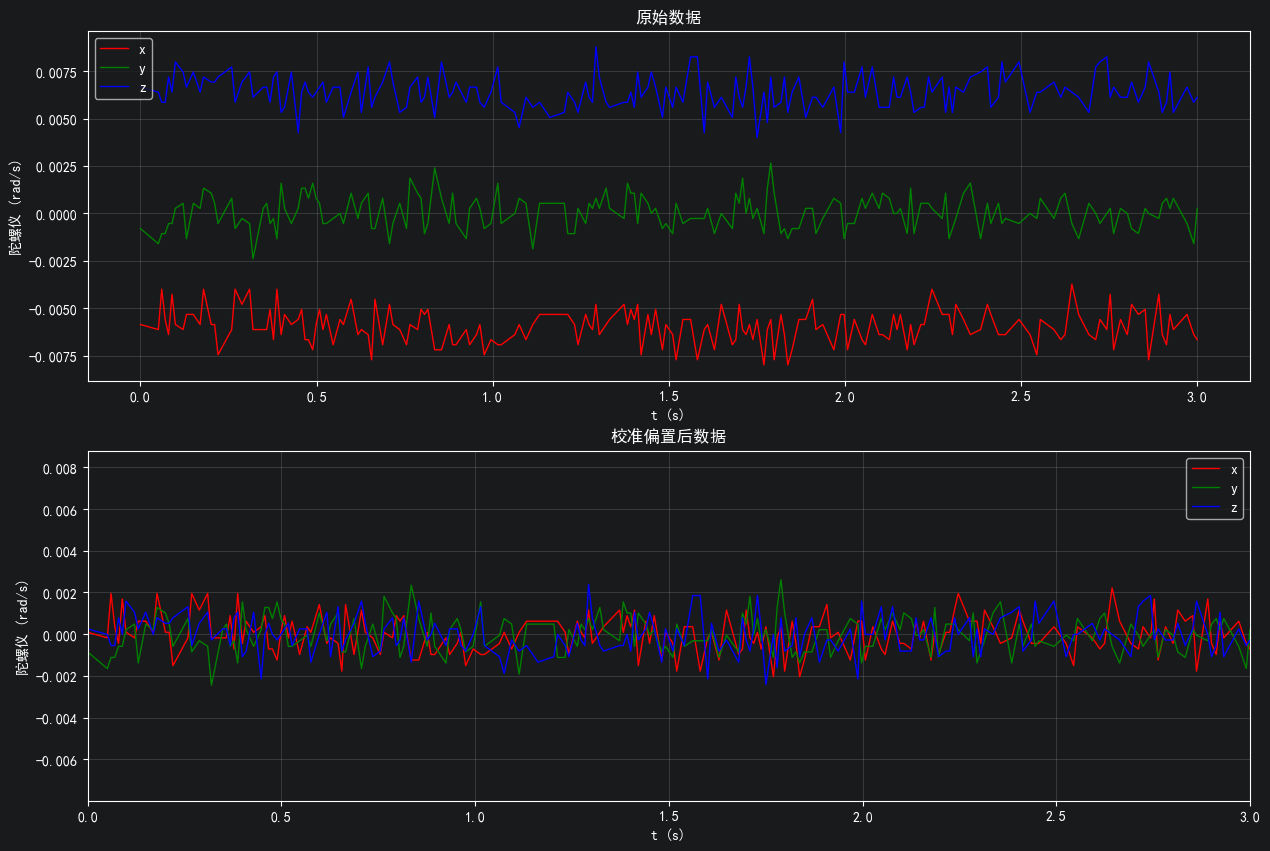

In [7]:
t_init_mask = timestamp < T_INIT
gyro_init = gyro[:, t_init_mask]
gyro_bias = gyro_init.mean(axis=1)
print(f"gyro_bias: {gyro_bias}")
gyro_bias_free = gyro - gyro_bias.reshape(3, 1)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for i in range(gyro_init.shape[0]):
    axes[0].plot(timestamp[t_init_mask], gyro_init[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[0].set_title("原始数据")
axes[0].set_xlabel("t (s)")
axes[0].set_ylabel('陀螺仪 (rad/s)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i in range(gyro_bias_free.shape[0]):
    axes[1].plot(timestamp, gyro_bias_free[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[1].set_title("校准偏置后数据")
axes[1].set_xlabel("t (s)")
axes[1].set_ylabel('陀螺仪 (rad/s)')
axes[1].set_xlim(0, 3)
axes[1].set_ylim(gyro_init.min(), gyro_init.max())
axes[1].legend()
axes[1].grid(True, alpha=0.3)

## 找出静止区间
在给定的时间$t$, 基于特定的时间长度$t_w$，计算$\varsigma(t, t_w) = \sqrt{[var_{t_w}(a_x)]^2 +[var_{t_w}(a_y)]^2 +[var_{t_w}(a_z)]^2}$

首先对于$t\in[0, T_{init})$, 使用$t = T_{init}/2$与$t_w = T_{init}$计算$\varsigma_{init}$

对于


In [8]:
def varsigma2(acc: np.ndarray):
    """根据给定的acc切片(3, n)，计算各轴方差的平方和"""
    var = np.var(acc, axis=1)
    return np.sum(var * var)


def interval_to_indices(static_interval: np.ndarray) -> tuple[list[slice], list[slice]]:
    indices = np.r_[0, np.where(np.diff(static_interval) != 0)[0] + 1, len(static_interval)]
    moving = []
    static = []
    for i in range(len(indices) - 1):
        s = slice(indices[i], indices[i + 1])
        if static_interval[indices[i]] == 0:
            moving.append(s)
        else:
            static.append(s)
    return moving, static


class AccResults:
    def __init__(self, threshold: float, static_intervals: np.ndarray):
        self.threshold = threshold
        self.static_intervals = static_intervals
        self.moving_slice, self.static_slice = interval_to_indices(self.static_intervals)
        self.acc_params = np.array([0, 0, 0, 1, 1, 1, 0, 0, 0])
        self.residual = 0
        self.is_success = False

    def reset(self):
        self.acc_params = np.array([0, 0, 0, 1, 1, 1, 0, 0, 0])
        self.residual = 0
        self.is_success = False


varsigma_init: float = varsigma2(acc[:, t_init_mask])
print(f"varsigma_init: {varsigma_init}")

n_samples = len(timestamp)
half_window_size = int(T_WAIT / 2)
result_list: list[AccResults] = []
for k in tqdm(range(1, N_ITER + 1)):
    threshold = k * varsigma_init
    static_intervals = np.zeros(n_samples, dtype=np.int8)
    for i in range(n_samples):
        t = timestamp[i]
        if t < half_window_size:
            static_intervals[i] = 1
            continue
        if t > timestamp[-1] - half_window_size:
            static_intervals[i] = 1
            continue
        window = (timestamp > t - half_window_size) & (timestamp < t + half_window_size)
        # Compute variance
        window_var = varsigma2(acc[:, window])
        if window_var < threshold:
            static_intervals[i] = 1
    result_list.append(AccResults(threshold, static_intervals))
    # plt.figure(figsize=(20,10))
    # plt.plot(static_intervals * 10)
    # for j in range(acc.shape[0]):
    #     plt.plot(acc[j], color=colors[j])
    # plt.title(f"Static detector at k = {k}")

varsigma_init: 3.14187821935318e-08


100%|██████████| 50/50 [00:05<00:00,  8.36it/s]


In [9]:
def acc_calib_matrix_from_params(theta: np.ndarray):
    T = np.array([
        [1, -theta[0], +theta[1]],
        [0, 1, -theta[2]],
        [0, 0, 1],
    ])
    K = np.array([
        [theta[3], 0, 0],
        [0, theta[4], 0],
        [0, 0, theta[5]],
    ])
    b = theta[6:9].reshape(3, 1)
    return T, K, b


def calibrate_acc(acc_measure: np.ndarray, T: np.ndarray, K: np.ndarray, b: np.ndarray) -> np.ndarray:
    return T @ K @ (acc_measure + b)


def acc_residual(acc_params: np.ndarray, acc_mean: np.ndarray):
    """
    theta_acc = [alpha_yz, alpha_zy, alpha_zx, s^a_x, s^a_y, s^a_z, b^a_x, b^a_y, b^a_z]
    """
    T, K, b = acc_calib_matrix_from_params(acc_params)
    acc_calib = calibrate_acc(acc_mean, T, K, b)

    acc_norm_sq = np.sum(acc_calib ** 2, axis=0)
    return G_EARTH ** 2 - acc_norm_sq


def optimize_acc(acc: np.ndarray, result: AccResults):
    param_init = result.acc_params
    static_acc_slices = [acc[:, s] for s in result.static_slice]
    acc_mean_arr = np.hstack([acc_slice.mean(axis=1).reshape(3, 1) for acc_slice in static_acc_slices])
    r = least_squares(
        acc_residual,
        param_init,
        args=(acc_mean_arr,),
        method='lm',
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-10,
        max_nfev=10000,
    )
    result.acc_params = r.x
    result.residual = r.cost
    result.is_success = r.success

In [10]:
for r in tqdm(result_list):
    r.reset()
    optimize_acc(acc, r)

success_results = list(filter(lambda r: r.is_success, result_list))

best_acc_result = min(success_results, key=lambda r: r.residual)
acc_params = best_acc_result.acc_params

100%|██████████| 50/50 [00:00<00:00, 1314.10it/s]


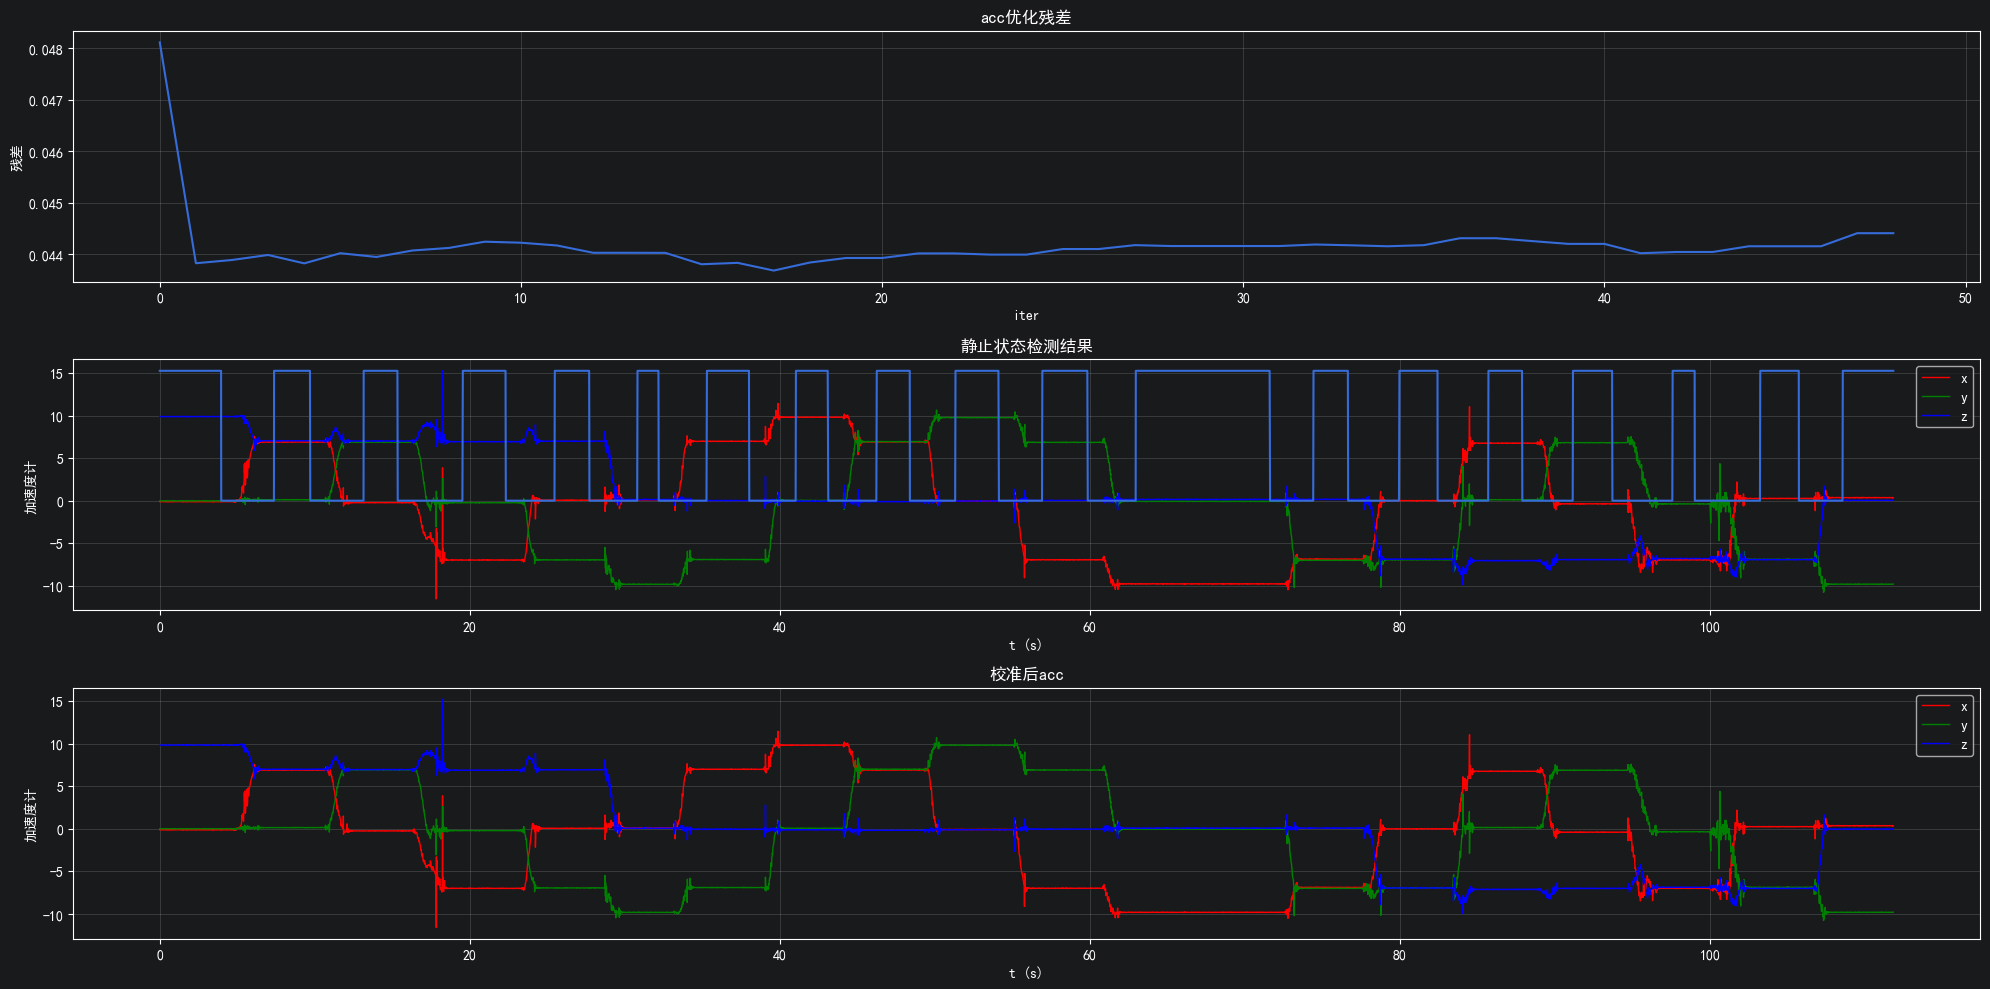

T:
[[ 1.00000000e+00 -1.34175434e-03  7.98896904e-04]
 [ 0.00000000e+00  1.00000000e+00 -4.23245341e-04]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
K:
[[0.99973039 0.         0.        ]
 [0.         0.99997841 0.        ]
 [0.         0.         0.99874867]]
b:
[[-0.01839611]
 [ 0.02870098]
 [-0.07149834]]


In [11]:
T_a, K_a, b_a = acc_calib_matrix_from_params(best_acc_result.acc_params)

acc_calibrated = calibrate_acc(acc, T_a, K_a, b_a)

fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# 优化残差
axes[0].plot([r.residual for r in success_results][1:])
axes[0].set_xlabel('iter')
axes[0].set_ylabel('残差')
axes[0].set_title('acc优化残差')
axes[0].grid(True, alpha=0.3)

# 静态区间
for i in range(3):
    axes[1].plot(timestamp, acc[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[1].plot(timestamp, best_acc_result.static_intervals * acc.max())
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('加速度计')
axes[1].set_title('静止状态检测结果')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 静态区间
for i in range(3):
    axes[2].plot(timestamp, acc_calibrated[i], label=axes_labels[i], color=colors[i], linewidth=1)
axes[2].set_xlabel('t (s)')
axes[2].set_ylabel('加速度计')
axes[2].set_title('校准后acc')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("T:")
print(T_a)
print("K:")
print(K_a)
print("b:")
print(b_a)

In [12]:
for i in range(3):
    print(acc_calibrated[i][t_init_mask].min())
print(np.linalg.norm(acc_calibrated[:, t_init_mask], axis=0).mean())

-0.1541630188430077
-0.032918967857474134
9.789923893794782
9.81719930297494


单步积分$\omega$:
$$f(q,t) = \dot{q} = \frac{1}{2}\Omega(\omega(t))q$$
$$
\Omega(\omega) = \begin{bmatrix}
0 & -\omega_x & -\omega_y & -\omega_z \\
\omega_x & 0 & \omega_z & -\omega_y \\
\omega_y & -\omega_z & 0 & \omega_x \\
\omega_z & \omega_y & -\omega_x & 0 \\
\end{bmatrix}
$$
计算：
$$L(\theta^{gyro}) = \sum_{k=2}^{M} ||u_{a,k} - u_{g,k}||$$
其中$u_{a,k}$为加速度计结果，$u_{g,k}$为从k-1时刻积分得到的预测加速度计结果，
$$\theta^{gyro} = \begin{bmatrix} \gamma_{yz} & \gamma_{zy} & \gamma_{xz} & \gamma_{zx} & \gamma_{xy} & \gamma_{yx} & s_x^g & s_y^g & s_z^g \end{bmatrix}$$
且
$$
T^g = \begin{bmatrix}
1 & -\gamma_{yz} & \gamma_{zy} \\
\gamma_{xz} & 1 & -\gamma_{zx} \\
-\gamma_{xy} & \gamma_{yx} & 1\\
\end{bmatrix}
$$
$$
K^g = \begin{bmatrix}
s_x^g & 0 & 0 \\
0 & s_y^g & 0  \\
0 & 0 & s_z^g  \\
\end{bmatrix}
$$
$$\omega^O = T^gK^g(\omega^S + b^g)$$
其中$b^g$直接从第一个测量结果的平均值得到

实现中 gyro 数据索引为 `data[4:7]`。

In [13]:
def omega_matrix(omega: np.ndarray) -> np.ndarray:
    wx, wy, wz = omega
    return np.array([
        [0.0, -wx, -wy, -wz],
        [wx, 0.0, wz, -wy],
        [wy, -wz, 0.0, wx],
        [wz, wy, -wx, 0.0],
    ])


def quat_derivative(q: np.ndarray, omega: np.ndarray) -> np.ndarray:
    return 0.5 * omega_matrix(omega) @ q


def normalize_quaternion(q: np.ndarray) -> np.ndarray:
    return q / np.linalg.norm(q)

def matrix_from_gyro_params(theta: np.ndarray):
    T = np.array([
        [1.0, -theta[0], theta[1]],
        [theta[2], 1.0, -theta[3]],
        [-theta[4], theta[5], 1.0],
    ])
    K = np.diag(theta[6:9])
    return T, K


def calibrate_gyro(gyro_bias_free: np.ndarray, T: np.ndarray, K: np.ndarray) -> np.ndarray:
    return T @ K @ gyro_bias_free


def rk4_step(q0: np.ndarray, omega_0: np.ndarray, omega_1: np.ndarray, dt: float) -> np.ndarray:
    """
    对旋转方程做t0-t1时刻的单步积分
    :param q0: t0时刻的四元数
    :param omega_0: t0时刻的角速度（陀螺仪读数）
    :param omega_1: t1时刻的角速度（陀螺仪读数）
    :param dt: t1-t0
    :return: 积分得到的单位四元数
    """
    omega_mid = 0.5 * (omega_1 + omega_0)

    k1 = quat_derivative(q0, omega_0)
    k2 = quat_derivative(q0 + 0.5 * dt * k1, omega_mid)
    k3 = quat_derivative(q0 + 0.5 * dt * k2, omega_mid)
    k4 = quat_derivative(q0 + dt * k3, omega_1)

    q1 = q0 + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return normalize_quaternion(q1)


def rk4_gyro_interval(gyro: np.ndarray, timestamp: np.ndarray) -> np.ndarray:
    q = np.array([1.0, 0.0, 0.0, 0.0])
    for i in range(len(timestamp) - 1):
        dt = timestamp[i + 1] - timestamp[i]
        q = rk4_step(q, gyro[:, i], gyro[:, i + 1], dt)
    return q


def gyro_cost_single(params_gyro: np.ndarray, timestamp: np.ndarray, acc_calibrated: np.ndarray,
                     gyro_biasfree: np.ndarray):
    """
    单段数据的残差
    :param params_gyro: 陀螺仪校准参数
    :param timestamp: 时间戳数组
    :param acc_calibrated: 校准后的加速度
    :param gyro_biasfree: 校准偏置后的陀螺仪
    :return:
    """
    T, K = matrix_from_gyro_params(params_gyro)
    gyro_calibrated = calibrate_gyro(gyro_biasfree, T, K)
    q = rk4_gyro_interval(gyro_calibrated, timestamp)
    a_0 = acc_calibrated[:, 0]
    a_0 = a_0 / np.linalg.norm(a_0)
    a_k = acc_calibrated[:, -1]
    a_k = a_k / np.linalg.norm(a_k)
    rot = Rotation.from_quat(np.roll(q,-1)) # 转换为[x, y, z, w]
    a_g = rot.apply(a_0, inverse=True)
    a_g = a_k / np.linalg.norm(a_g)
    diff = a_g - a_k
    # return np.sum(diff * diff)
    return np.linalg.norm(diff)


def gyro_cost(params_gyro: np.ndarray, timestamp: np.ndarray, acc_calibrated: np.ndarray, gyro_bias_free: np.ndarray,
              acc_result: AccResults) -> np.ndarray:
    slices = acc_result.moving_slice
    costs = np.zeros(len(slices))
    for i, s in enumerate(slices):
        costs[i] = gyro_cost_single(params_gyro, timestamp[s], acc_calibrated[:, s], gyro_bias_free[:, s])
    # return costs.sum()
    return costs

In [14]:
params_gyro_init = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1])
result_gyro = least_squares(
    gyro_cost,
    params_gyro_init,
    args=(timestamp, acc_calibrated, gyro_bias_free, best_acc_result,),
    method='lm',
    ftol=1e-10,
    xtol=1e-10,
    gtol=1e-10,
    max_nfev=4000,
)
# result_gyro =  minimize(
#     gyro_cost,
#     params_gyro_init,
#     args=(timestamp, acc_calibrated, gyro_bias_free, best_acc_result),
#     method='Powell',
#     tol=1e-10,
#     options={"maxiter": 2e4, "disp": True, "xtol": 1e-8, "ftol": 1e-9},
# )
print("Success: ", result_gyro.success)
print("Cost: ", result_gyro.fun)
gyro_params = result_gyro.x
T_g, K_g = matrix_from_gyro_params(gyro_params)
print('T_g:')
print(T_g)
print('K_g:')
print(K_g)

Success:  True
Cost:  [0.00000000e+00 0.00000000e+00 1.57047574e-16 1.57011642e-16
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.57009845e-16 1.57047574e-16 1.57162500e-16 0.00000000e+00
 1.57162500e-16 2.22153422e-16]
T_g:
[[ 1.00000000e+00 -9.44627275e-09 -5.78821254e-09]
 [ 8.17327398e-09  1.00000000e+00 -6.50276419e-10]
 [ 2.75081726e-09  7.18490800e-09  1.00000000e+00]]
K_g:
[[0.99999999 0.         0.        ]
 [0.         1.00000001 0.        ]
 [0.         0.         1.        ]]


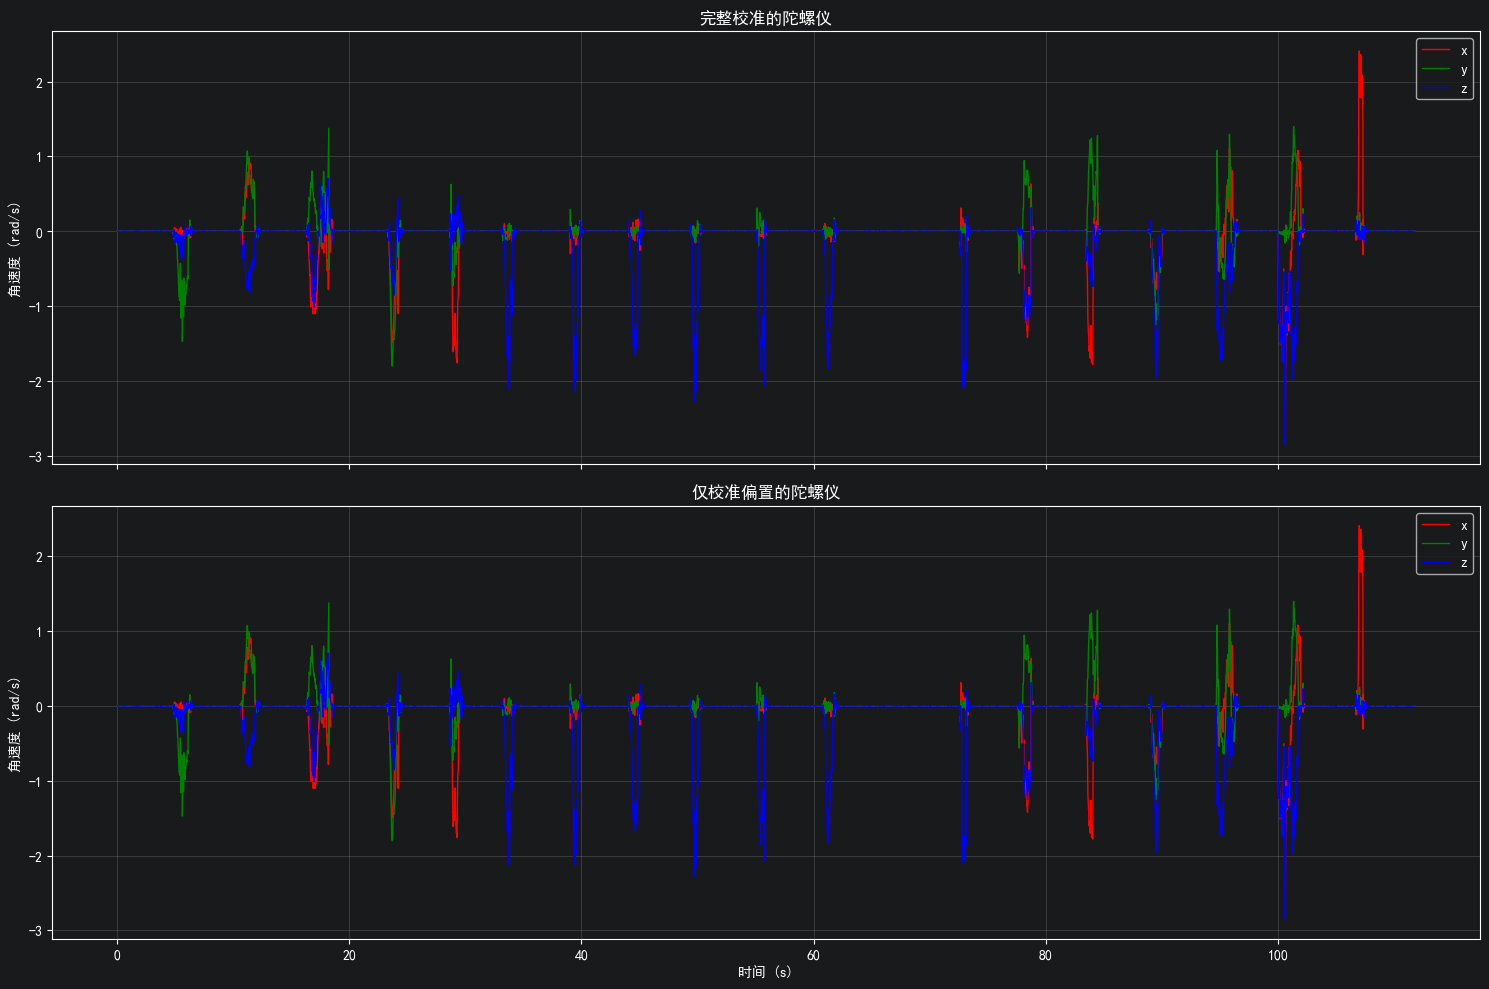

In [15]:
gyro_calibrated = calibrate_gyro(gyro_bias_free, T_g, K_g)
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for i in range(3):
    axes[0].plot(timestamp, gyro_calibrated[i], label=axes_labels[i], color=colors[i], linewidth=1)
    axes[1].plot(timestamp, gyro_bias_free[i], label=axes_labels[i], color=colors[i], linewidth=1)

axes[0].set_ylabel('角速度 (rad/s)')
axes[0].set_title('完整校准的陀螺仪')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('时间 (s)')
axes[1].set_ylabel('角速度 (rad/s)')
axes[1].set_title('仅校准偏置的陀螺仪')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
from scipy.io import savemat

MAT_FILENAME = f"param_imu_{IMU_ID:03d}.mat"
mat_path = DATASET_DIR / MAT_FILENAME

savemat(mat_path, {
    'acc_params': acc_params.ravel(),
    'gyro_params': gyro_params.ravel(),
    'T_a': T_a,
    'K_a': K_a,
    'b_a': b_a,
    'T_g': T_g,
    'K_g': K_g,
    'b_g': -gyro_bias,
})

print(f'saved: {mat_path.absolute()}')


saved: D:\Codes\slime\PixelSlimeHost\HostApplication\bin\Debug\net10.0\imu-data\20260423_225411\param_imu_002.mat
